# QF 627 Programming and Computational Finance
## Problem Set `6` | `Questions`

> Hi, Team. 👋

> Here we go again. The current notebook contains 7 questions that help you review our course content.

> Try to answer questions within a 90-minute time limit (and you may refer to lecture notes and review scripts while you are answering). This kind of timed task will improve your performance and prepare you well for the assessment down the line. Once you complete this, submit your script via eLearn.

> Enjoy!"🤞

### For standardization of your answers…

> Please execute the lines of code below before you start work on your answers.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## 👇 Questions 1 to 4 ask you to build, execute, and backtest a `mean-reversion` strategy.

### <font color = blue> 👉 Question 1</font>. Let’s take a look at Google (`GOOGL`) as our security of interest, over the period of August 2011 to July 2020.

### Use a simple moving average of 42 days.

### Set a threshold value at two standard deviations of the current price, to deviate from the simple moving average to signal a positioning.

### <font color = green> NOTE: Your moving threshold value here is NOT an absolute value. You should create two additional columns containing your two standard deviations relative to your base line (a simple moving average of 42 days). </font>

### Visualize your buy and sell positions.

### Below are the lines of code that lead to an answer:

In [3]:
g = \
yf.download(
    ['GOOGL'],
    start = '2011-01-01',
    end = '2020-08-01'
)['Close']

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_50397/2374108538.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(
[*********************100%***********************]  1 of 1 completed


In [4]:

g['sma_42'] = g['GOOGL'].rolling(42).mean()
absolute_distance_threshold = 2 * g['GOOGL'].rolling(42).std()
g["distance"] = g['GOOGL'] - g['sma_42']
g["positions"] =\
(
    np.where(g["distance"] > absolute_distance_threshold,
             -1, np.nan)
)

# Detect over-sold --> price will go up --> Buy

g["positions"] =\
(
    np.where(g["distance"] < -absolute_distance_threshold,
             1, g["positions"]
            ) # team, make sure to carry over the position that you have set above
)

# Detect Volatile Market --> it's too early to call --> Market Neutral Position (Hold)

g["positions"] =\
(
    np.where(g["distance"] * g["distance"].shift(1) < 0,
             0, g["positions"]
            )
)
g['positions'] = g['positions'].ffill()
g = g.loc['2011-08-01': '2020-08-01']
g['trade'] = g['positions'].diff().fillna(g.at[g.index[0], 'positions'])

### <font color = red> Answer 1 is presented in the cell below: </font>

In [5]:
# TODO get_plot lets-plot; basic 
from lets_plot import *
LetsPlot.setup_html()

g_melt = g.reset_index()
# g_melt = g_melt.rename(columns={'index':'Date'}). # optional depending if index is called 'Date'

p =\
(
    ggplot(g_melt, aes(x='Date')) +
    geom_line(aes(y='GOOGL'), color='grey', size=0.7) +
    geom_line(aes(y='sma_42'), color='orange', size=0.7,linetype=2) +   # amend sma as required
    # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
    geom_point(aes(y='sma_42'), data=g_melt[g_melt['trade']>0.0], color='red', size=3) +       # amend trade as required
    geom_point(aes(y='sma_42'), data=g_melt[g_melt['trade']<-0.0], color='blue', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)


p

In [6]:
g['trade'].value_counts()

trade
 0.0    2177
-1.0      45
 1.0      44
Name: count, dtype: int64

(<AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>)

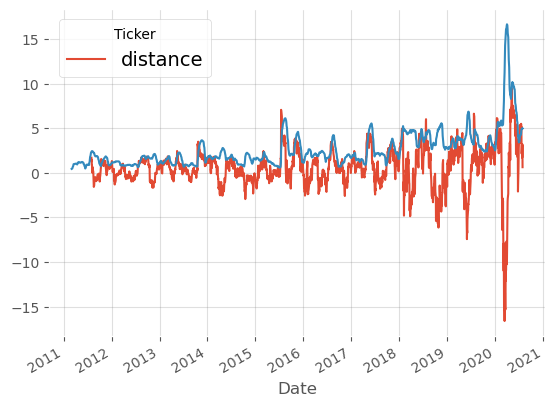

In [7]:
g[['distance']].plot(), absolute_distance_threshold.plot()

### <font color = blue> 👉 Question 2</font>. Let’s expand this strategy to two more securities, Apple (`AAPL`) and Amazon (`AMZN`) over the same period of August 2011 to July 2020. 

### When using the strategy above, which of those two securities has the greater Sharpe Ratio?

### Below are the lines of code that lead to an answer:

In [8]:
tickers = ["AAPL", "AMZN"]
stock_data = yf.download(tickers,
            start = dt.datetime(2011, 1, 1),
            end = dt.datetime(2020, 8, 1))['Close']

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_50397/2828465484.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(tickers,
[*********************100%***********************]  2 of 2 completed


In [9]:
dct = {}

for ticker in tickers:
    df = stock_data[[ticker]]
    
    df['sma_42'] = df[df.columns[0]].rolling(42).mean()
    absolute_distance_threshold = 2 * df[df.columns[0]].rolling(42).std()
    df["distance"] = df[df.columns[0]] - df['sma_42']
    df["positions"] =\
    (
        np.where(df["distance"] > absolute_distance_threshold,
                 -1, np.nan)
    )

    # Detect over-sold --> price will go up --> Buy

    df["positions"] =\
    (
        np.where(df["distance"] < -absolute_distance_threshold,
                 1, df["positions"]
                ) # team, make sure to carry over the position that you have set above
    )

    # Detect Volatile Market --> it's too early to call --> Market Neutral Position (Hold)

    df["positions"] =\
    (
        np.where(df["distance"] * df["distance"].shift(1) < 0,
                 0, df["positions"]
                )
    )
    df['positions'] = df['positions'].ffill()
    df = df.loc['2011-08-01': '2020-08-01']
    df['trade'] = df['positions'].diff().fillna(df.at[df.index[0], 'positions'])
    
    df['passive_returns'] = \
    (
        np.log(
            df[df.columns[0]] / 
                df[df.columns[0]].shift(1)
        )
    ).fillna(0)
    df['strategy_returns'] = \
    (
        df['passive_returns'] * df['positions'].shift(1).fillna(0)
    )
    df['cum_passive_returns'] = \
    (
        df['passive_returns'].cumsum().apply(np.exp).fillna(1)
    )
    df['cum_strategy_returns'] = \
    (
        df['strategy_returns'].cumsum().apply(np.exp).fillna(1)
    )

    dct[ticker] = df

In [10]:
def compute_sharpe_ratio(daily_returns):
    """
    get_sharpe Calculate the annualized Sharpe ratio from a series of daily returns.
    Annualized Sharpe ratio computed as:
                sqrt(252) * mean(daily_returns) / std(daily_returns)
    - Assumes 252 trading days per year for annualization. Adjust the
      multiplier for a different convention.
    - Input should be returns (not prices). Convert prices to returns before
      calling this function.
    Parameters:
        daily_returns : array-like (pd.Series or np.ndarray)
    Returns:
        float
    Usage:
        compute_sharpe_ratio(df['strategy_returns'])
    """
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std(ddof = 1)

# compute_sharpe_ratio(ibm['strategy_returns'])

In [11]:
for ticker, df in dct.items():
    sharpe = compute_sharpe_ratio(df['strategy_returns'])
    print(f"{ticker} has {sharpe:.5f}")

AAPL has -0.31345
AMZN has -0.07933


### <font color = red> Answer 2 </font>

    The answer is ____________ .

In [12]:
f"The answer is AMZN"

'The answer is AMZN'

### <font color = blue> 👉 Question 3</font>. Let’s suppose that you started from a `$200,000` capital base for each of the three securities.

### Disregarding commission, how much will you have in the end in your account for each of the securities as a result of the mean-reversion strategy-based trading?

### Below are the lines of code that lead to an answer:

In [13]:
g['passive_returns'] = \
(
    np.log(
        g[g.columns[0]] / 
            g[g.columns[0]].shift(1)
    )
).fillna(0)
g['strategy_returns'] = \
(
    g['passive_returns'] * g['positions'].shift(1).fillna(0)
)
g['cum_passive_returns'] = \
(
    g['passive_returns'].cumsum().apply(np.exp).fillna(1)
)
g['cum_strategy_returns'] = \
(
    g['strategy_returns'].cumsum().apply(np.exp).fillna(1)
)

dct['GOOGL'] = g

In [14]:
for ticker, df in dct.items():
    print(f"{ticker}: ${df.iloc[-1]['cum_strategy_returns'] * 200_000 :,.2f}")

AAPL: $103,716.12
AMZN: $167,950.21
GOOGL: $260,817.37


### <font color = red> Answer 3 </font>

    GOOGL : ____________ 
    
    AAPL  : ____________ 
     
    AMZN  : ____________ 
    

### <font color = blue> 👉 Question 4</font>. What are the compound annual growth rates of each of the securities, based on the current mean-reversion strategy-based trading? 

### Below are the lines of code that lead to an answer:

In [15]:
def compute_CAGR(cumulative_returns):
    """
    get_cagr Compute Compound Annual Growth Rate (CAGR) from a series of cumulative returns.
        - The function drops missing values and uses the first and last available
      observations to compute CAGR as:
          (last_value / first_value) ** (365.0 / n_days) - 1
      where n_days is the integer number of days between the first and last index.
        - Uses 365-day convention for annualization. For trading-day conventions
        adjust the exponent accordingly.
        - If the series contains a single observation or zero-day span, the result
        may be ill-defined (division by zero or power of inf). Consider checking
        the index span before calling.
    Parameters:
        cumulative_returns : pandas.Series. Time-indexed series of cumulative returns (e.g. cumulative growth factors)
    Returns:
        float
    """

    cumulative_returns = cumulative_returns.dropna()
    n_of_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]
                ).days
    cagr =\
    (
        (        
        cumulative_returns.iloc[-1] 
        /
        cumulative_returns.iloc[0]
        ) ** (365.25 / n_of_days)
        - 1
    )
    return cagr

In [16]:
for ticker, df in dct.items():
    print(f"{ticker}: {compute_CAGR(df['cum_strategy_returns']):.2%}")

AAPL: -7.04%
AMZN: -1.92%
GOOGL: 2.99%


### <font color = red> Answer 4 </font>

    GOOGL : ____________ 
    
    AAPL  : ____________ 
     
    AMZN  : ____________ 

## 👇 Questions 5 to 8 ask you to build, execute, and backtest a momentum strategy.

###  <font color = blue> 👉 Question 5. </font> Our securities of interest are Goldman Sachs (`GS`) and JP Morgan Chase (`JPM`) stock. The time period for analysis is from November 2013 to October 2021.

### Here’s our use of the momentum indicator, reflecting the moving averages of stock prices for trend following.

### The two moving windows are 24 days and 58 days.

### Calculate and visualize the maximum drawdowns and the longest drawdown periods for `GS` and `JPM`.

### Below are the lines of code that lead to an answer:

In [55]:
tickers = ['GS','JPM']

# TODO yf download
stock_data=\
yf.download(
    tickers,
    start = '2013-01-01',
    end = '2021-11-01'
)['Close']

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_50397/4253012934.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(
[*********************100%***********************]  2 of 2 completed


In [56]:
def get_momentum_strategy(df, sma_tuple, date_range):
    """
    Apply single stock momentum strategy pipeline to price DataFrame `df`. 
    Price is in first column.
    Adds columns:
      positions, trade, passive_returns, strategy_returns,
      cum_returns, cum_strategy_returns
    Parameters:
      df        : pd.DataFrame with price columns for ticker name as the header
      sma_tuple : tuple of (short_window, long_window) for SMAs
    Returns:
      pd.DataFrame with the above columns
    """
    def get_sma(df, sma_list):
        """
        Take DF and given list of SMA to enrich df when stock price is in first column
        """
        for window in sma_list:
            df[f"sma_{window}"] =\
            (
                df[df.columns[0]]
                .rolling(window = window,
                         min_periods = int(window * .8))
                .mean()
            )

        return df
    sma_short, sma_long = sma_tuple
    if sma_short >= sma_long:
        raise ValueError("sma_short must be less than sma_long")
    df = get_sma(df, list(sma_tuple)).dropna()

    df['positions'] =\
    (
        np.where((df[f'sma_{sma_short}'] > df[f'sma_{sma_long}']), 1, -1)
    )
    
    # set obs period
    df = df.loc[ date_range[0] : date_range[1]]
    
    df['trade'] = \
    (
        df['positions'].diff().fillna(0)
    )
    if df.loc[df.index[0], 'positions'] != 0:
        df.at[df.index[0], 'trade'] = df.loc[df.index[0], 'positions']
    df['passive_returns'] =\
    (    # get passive returns
        np.log(df[df.columns[0]] 
            / df[df.columns[0]].shift(1))
    ).fillna(0)
    df['strategy_returns'] =\
    (     # get strategy returns
        df['passive_returns'] * df['positions'].shift(1).fillna(0)
    )
    df['cum_returns'] =\
    (
        df['passive_returns'].cumsum().apply(np.exp).fillna(1)
    )
    df['cum_strategy_returns'] =\
    (
        df['strategy_returns'].cumsum().apply(np.exp).fillna(1)
    )

    return df



In [57]:
sma_tup = (24, 58)
date_range_ =['2013-11-01','2021-11-01']

stock_dct = {}

for ticker in tickers:
    stock_dct[ticker] = get_momentum_strategy(stock_data[[ticker]], sma_tup, date_range_)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_50397/2785955922.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['positions'] =\
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_50397/2785955922.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['positions'] =\


In [ ]:
# plot drawdowns
from lets_plot import *
LetsPlot.setup_html()

def get_drawdowns_plot(cum_returns):

    daily_drawdown = cum_returns / cum_returns.cummax() - 1
    df['daily_drawdown'] = df['cum_returns'] / df['cum_returns'].cummax() - 1
    # take date column out and cumsum for periods
    dd_reset = df.reset_index()
    dd_reset['period'] = (dd_reset['daily_drawdown'] == 0).cumsum()
    # find nodes with 0 value i.e. highpoints
    dd_nonzero = dd_reset[dd_reset['daily_drawdown'] != 0]
    # aggregate by period
    period_stats = dd_nonzero.groupby('period').agg(
        start_date = ('Date', 'min'),
        end_date = ('Date', 'max'),
        avg_dd = ('daily_drawdown', 'mean'),
        max_dd = ('daily_drawdown', 'min'),
        duration=('daily_drawdown', 'count')
    ).sort_values(by='avg_dd',ascending=True)


    p =\
    (
        ggplot(dd_reset, aes(x='Date')) +
        geom_line(aes(y='daily_drawdown'), color='grey', size=0.7) +
        # geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +   # amend sma as required
        # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
        # geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']>0.0], color='red', size=3) +       # amend trade as required
        # geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']<-0.0], color='blue', size=3) +
        ggtitle(f"Drawdown for {ticker}") +
        ylab("pct loss") +
        scale_y_continuous(format='.0%') + 
        xlab("Date") +
        ggsize(1200, 500) 
    )
    display(p)
    
    print(f"    As to {ticker},\n")
    
    print(f"The maximum drawdown is about {period_stats.max_dd.min():.2%} percentage points.")
    print(f"The longest drawdown period lasts for {period_stats.duration.max():.0f} days.")
    
    
    return period_stats

### <font color = red> Answer 5 (`visualization with lets-plot`) is presented in the cell below: </font>

### <font color = red> Answer 5 </font>
    
    As to GS,
    
    The maximum drawdown is about ____________ percentage points.
    The longest drawdown period lasts for _____________ days.
    
    As to JPM,
    
    The maximum drawdown is about ____________ percentage points.
    The longest drawdown period lasts for _____________ days.
    

In [59]:
dd_dct = {}

for ticker, df in stock_dct.items():
    dd_dct[ticker] = get_drawdowns(df['cum_strategy_returns'])

    As to GS,

The maximum drawdown is about -0.04% percentage points.
The longest drawdown period lasts for 70400.00% days.


    As to JPM,

The maximum drawdown is about -0.07% percentage points.
The longest drawdown period lasts for 30400.00% days.


###  <font color = blue> 👉 Question 6. </font>  If you had started with a capital of $300,000 for each of the three securities, how much would be left in your account after trading according to your above strategies for `GS` and `JPM`?

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 6 </font>

    The answer is ____________________________ .

In [60]:
def get_end_cap(df):
    initial_cap = 300_000
    cap = initial_cap
    cum_strategy_returns = pd.Series(index=df.index)

    for idx, row in df.iterrows():
        cap *= np.exp(row['strategy_returns'])
        # if row['trade'] !=0:
        #     cap -= 5
        cum_strategy_returns.loc[idx] = cap

    print(f"The answer is ${cap:,.0f}")
    
for ticker, df in stock_dct.items():
    get_end_cap(df)

The answer is $769,290
The answer is $496,973


###  <font color = blue> 👉 Question 7. </font> Using the current momentum strategy, how many trading opportunities were there for GS and JPM?

### Below are the lines of code that lead to an answer:

In [61]:
def get_trade_count(df):
    trade_count = df['trade'][df['trade']!=0].count()

    print(f"The answer is {trade_count}")
    
for ticker, df in stock_dct.items():
    get_trade_count(df)

The answer is 39
The answer is 45


### <font color = red> Answer 7 </font>

    The answer is ____________________________ .

In [66]:
def plot_rets(df):
    dd_reset = df.reset_index()
    p =\
    (
        ggplot(dd_reset, aes(x='Date')) +
        geom_line(aes(y='cum_strategy_returns'), color='grey', size=0.7) +
        # geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +   # amend sma as required
        # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
        # geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']>0.0], color='red', size=3) +       # amend trade as required
        # geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']<-0.0], color='blue', size=3) +
        ggtitle(f"Drawdown for {ticker}") +
        ylab("cum return") +
        scale_y_continuous(format='.0%') + 
        xlab("Date") +
        ggsize(1200, 500) 
    )
    display(p)

for ticker, df in stock_dct.items():
    plot_rets(df)
    


> 💯 “Thank you for putting your efforts into the individual assessment questions” 😊